In [ ]:
!pip install gensim

In [ ]:
import pandas as pd
test_df = pd.read_csv('test.csv')
train_df = pd.read_csv('train.csv')
valid_df = pd.read_csv('val.csv')

print(test_df.head)
print(train_df.head)
print(valid_df.head)

<bound method NDFrame.head of                                                  review  sentiment
0     okay naman yung product, cute. sobrang tagal l...          4
1     maliit ang size l dapat xl kunin mo if 33 size...          2
2     the premium meats doesn't taste premium at all...          1
3     ang nakalagay ay 10m pero 5 meters lang pala a...          1
4     as usual ang ganda pa din. thanks seller and k...          3
...                                                 ...        ...
2097  receive kuna po ung order ko.super ganda po tl...          3
2098  medyo dismayado ako kc order ko is black masca...          1
2099  bukod ang tagal dumating e iba iba p ung foam ...          1
2100  fine it's loose and yung tela nya is manipis t...          2
2101           excellent bilis dumating. thanks seller.          3

[2102 rows x 2 columns]>
<bound method NDFrame.head of                                                  review  sentiment
0     tumatagal naman sya thank you seller 

In [ ]:
print(test_df.shape)
print(train_df.shape)
print(valid_df.shape)

(2102, 2)
(6306, 2)
(2102, 2)


In [ ]:
STUDENT_NUMBER = 2023172283

In [ ]:
# Preprocessing and Word2Vec
import numpy as np
import re
from gensim.models import Word2Vec

def simple_tokenizer(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)
    return text.split()

train_sentences = train_df['review'].apply(simple_tokenizer).tolist()
val_sentences = valid_df['review'].apply(simple_tokenizer).tolist()
test_sentences = test_df['review'].apply(simple_tokenizer).tolist()

# Training Word2Vec
w2v_model = Word2Vec(
    sentences=train_sentences,
    vector_size=300,
    window=7,
    min_count=2,
    sg=1,
    workers=4,
    seed=STUDENT_NUMBER
)

# Function to average word vectors for a sentence
def get_sentence_vector(sentence, model):
    # Filter out words not in the vocabulary
    vectors = [model.wv[word] for word in sentence if word in model.wv]

    if len(vectors) > 0:
        return np.mean(vectors, axis=0)
    else:
        # Return zero vector if no words found in vocab
        return np.zeros(model.vector_size)

# Vectorize all datasets
X_train = np.array([get_sentence_vector(s, w2v_model) for s in train_sentences])
X_val = np.array([get_sentence_vector(s, w2v_model) for s in val_sentences])
X_test = np.array([get_sentence_vector(s, w2v_model) for s in test_sentences])

y_train = train_df['sentiment']
y_val = valid_df['sentiment']
y_test = test_df['sentiment']

print("Data Vectorization complete.")

Data Vectorization complete.


/tmp/ipython-input-2654409861.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=train_df, palette='viridis')


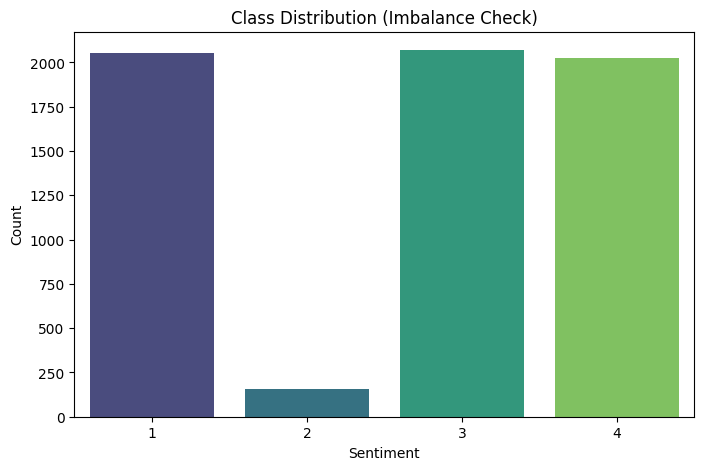

Generating 2x2 Unigram Analysis...


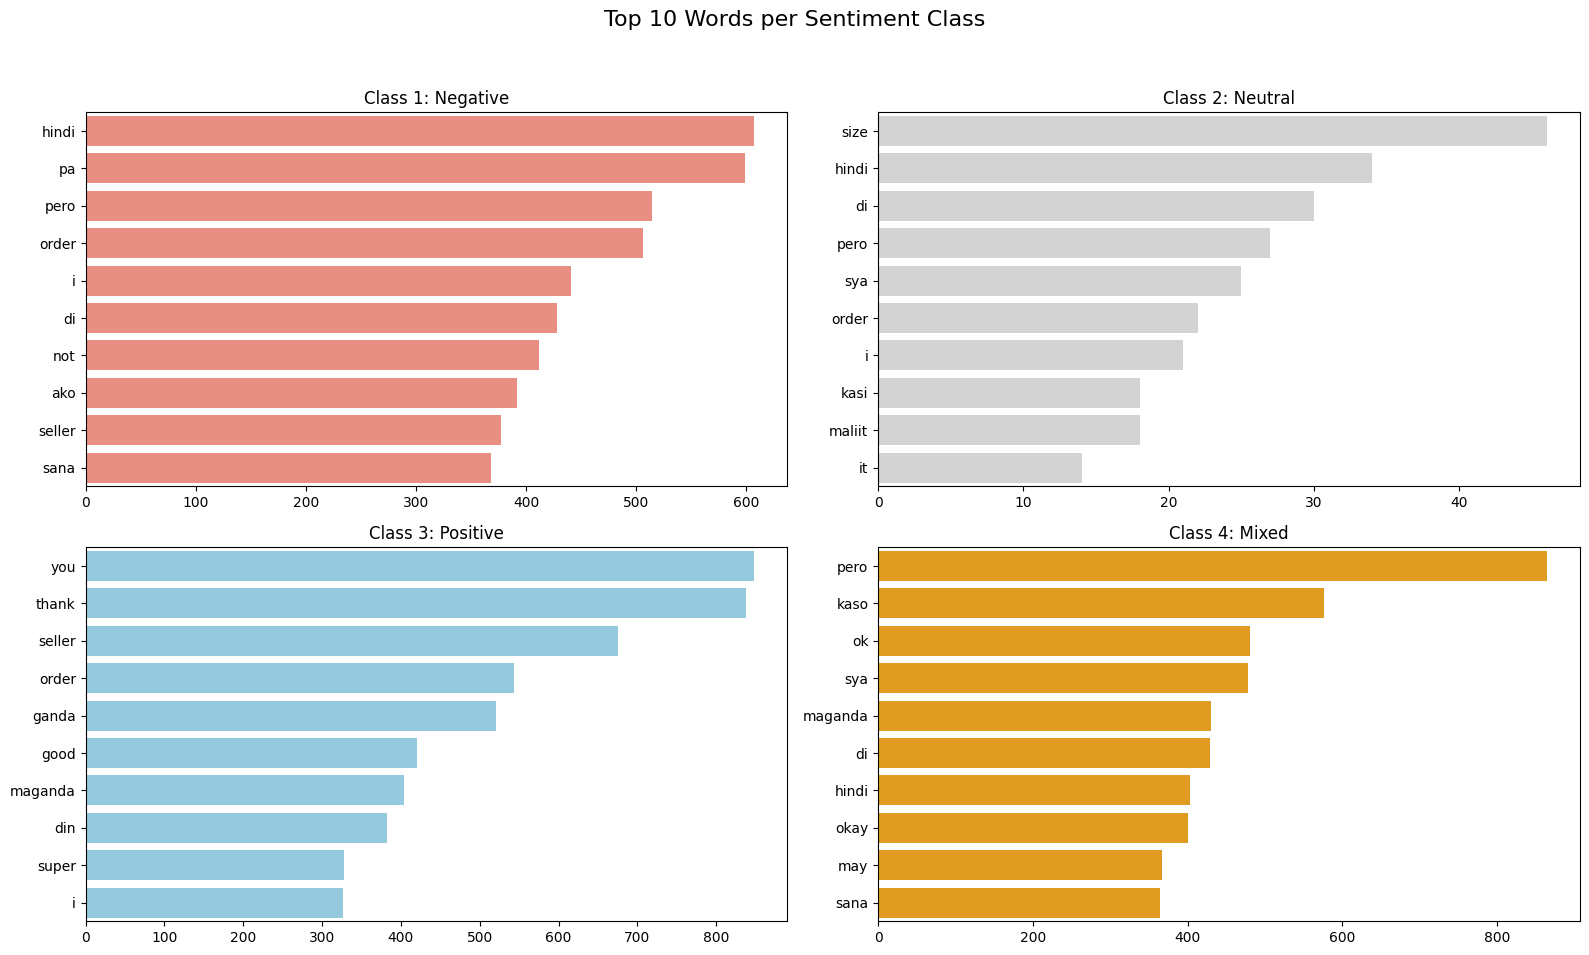

Generating Review Length Analysis...


/tmp/ipython-input-2654409861.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sentiment', y='word_count', data=train_df, palette='Set2')


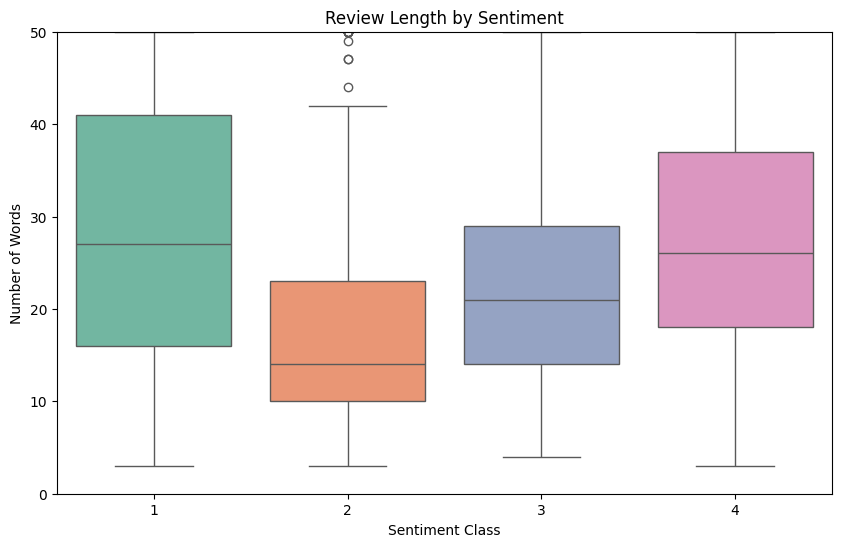

Generating t-SNE Plot...


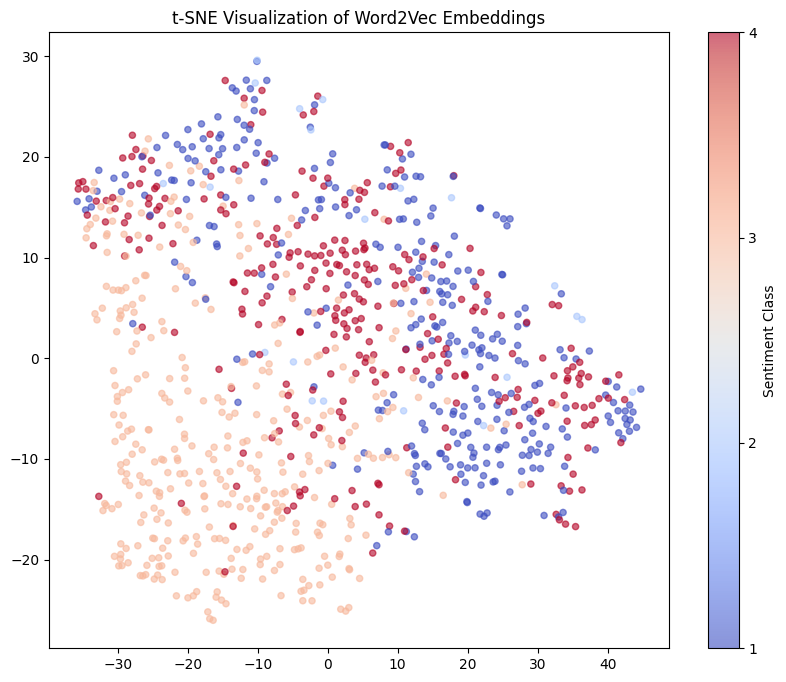

In [ ]:
#EDA

import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.manifold import TSNE

# CLASS DISTRIBUTION
plt.figure(figsize=(8, 5))
sns.countplot(x='sentiment', data=train_df, palette='viridis')
plt.title('Class Distribution (Imbalance Check)')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

# UNIGRAM ANALYSIS
print("Generating 2x2 Unigram Analysis...")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Top 10 Words per Sentiment Class', fontsize=16)
axes = axes.flatten()

sentiments = {1: 'Negative', 2: 'Neutral', 3: 'Positive', 4: 'Mixed'}
colors = ['salmon', 'lightgray', 'skyblue', 'orange']

stop_words = {'ang', 'sa', 'ng', 'na', 'the', 'is', 'and', 'to', 'of', 'a', 'in', 'for', 'ko', 'ung', 'my', 'yung', 'lang', 'ba', 'po', 'at', 'item', 'mo', 'naman'}

# Loop through each class and plot
for i, (label_code, label_name) in enumerate(sentiments.items()):
    # Filter data
    texts = train_df[train_df['sentiment'] == label_code]['review']

    # Tokenize and Clean
    all_words = " ".join(texts.astype(str)).lower().split()
    clean_words = [w for w in all_words if w not in stop_words]

    # Count Top 10
    counter = Counter(clean_words)
    top_10 = counter.most_common(10)
    words_df = pd.DataFrame(top_10, columns=['Word', 'Count'])

    # Plot on the specific subplot (axes[i])
    sns.barplot(x='Count', y='Word', data=words_df, ax=axes[i], color=colors[i])
    axes[i].set_title(f'Class {label_code}: {label_name}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# REVIEW LENGTH ANALYSIS
print("Generating Review Length Analysis...")

train_df['word_count'] = train_df['review'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
# Boxplot shows the median and outliers
sns.boxplot(x='sentiment', y='word_count', data=train_df, palette='Set2')
plt.title('Review Length by Sentiment')
plt.xlabel('Sentiment Class')
plt.ylabel('Number of Words')
plt.ylim(0, 50)
plt.show()

# t-SNE VISUALIZATION
print("Generating t-SNE Plot...")
subset_indices = np.random.choice(len(X_train), size=1000, replace=False)
X_subset = X_train[subset_indices]
y_subset = y_train.iloc[subset_indices]

tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca', learning_rate='auto')
X_embedded = tsne.fit_transform(X_subset)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=y_subset, cmap='coolwarm', alpha=0.6, s=20)
plt.colorbar(scatter, ticks=[1, 2, 3, 4], label='Sentiment Class')
plt.title('t-SNE Visualization of Word2Vec Embeddings')
plt.show()

In [ ]:
# Model Training
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

models = {
    "Logistic Regression": LogisticRegression(random_state=STUDENT_NUMBER, max_iter=1000),
    "SVM (Linear SVC)": SVC(kernel='linear', random_state=STUDENT_NUMBER),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=STUDENT_NUMBER)
}

best_model_name = ""
best_acc = 0
best_model = None
results = {}

# Train and Evaluate on Validation Set
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    val_preds = model.predict(X_val)
    acc = accuracy_score(y_val, val_preds)
    results[name] = acc
    print(f"  Validation Accuracy: {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_model_name = name
        best_model = model

print(f"\nBest Performing Model: {best_model_name} ({best_acc:.4f})")


Training Logistic Regression...
  Validation Accuracy: 0.7550
Training SVM (Linear SVC)...
  Validation Accuracy: 0.7569
Training Random Forest...
  Validation Accuracy: 0.7460

Best Performing Model: SVM (Linear SVC) (0.7569)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           1       0.74      0.78      0.76       660
           2       0.00      0.00      0.00        55
           3       0.85      0.81      0.83       686
           4       0.68      0.72      0.70       701

    accuracy                           0.75      2102
   macro avg       0.57      0.58      0.57      2102
weighted avg       0.73      0.75      0.74      2102



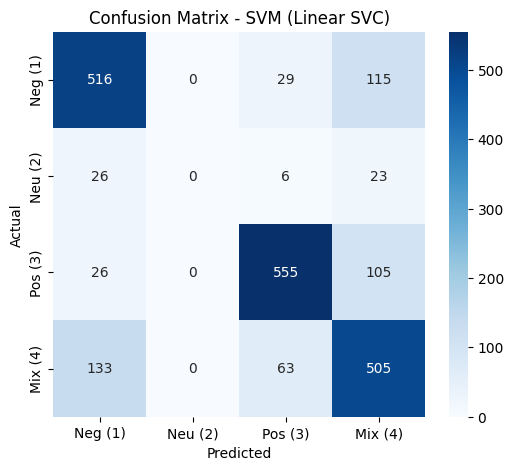

In [ ]:
# FINAL ANALYSIS: Test Set

test_preds = best_model.predict(X_test)
print(classification_report(y_test, test_preds))

# Confusion Matrix
cm = confusion_matrix(y_test, test_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Neg (1)', 'Neu (2)', 'Pos (3)', 'Mix (4)'],
            yticklabels=['Neg (1)', 'Neu (2)', 'Pos (3)', 'Mix (4)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()


In [ ]:
import pandas as pd

results = test_df.copy()
results['predicted'] = test_preds

sentiments = {1: "Negative", 2: "Neutral", 3: "Positive", 4: "Mixed"}

for label, name in sentiments.items():
    # Find errors for this class
    errors = results[(results['sentiment'] == label) & (results['predicted'] != label)]

    if not errors.empty:
        # Get the first available error
        sample = errors.iloc[0]['review']
        wrong_guess = sentiments[errors.iloc[0]['predicted']]

        print(f"CATEGORY: {name} (Actual {label}) Misclassified as {wrong_guess}")
        print(f"REVIEW SAMPLE: \"{sample}\"\n")

CATEGORY: Negative (Actual 1) Misclassified as Mixed
REVIEW SAMPLE: "the premium meats doesn't taste premium at all. the lechon belly is all rice! parang naging sahog lang ung lechon sa fried rice! …"

CATEGORY: Neutral (Actual 2) Misclassified as Negative
REVIEW SAMPLE: "maliit ang size l dapat xl kunin mo if 33 size ng hobby mo ..."

CATEGORY: Positive (Actual 3) Misclassified as Mixed
REVIEW SAMPLE: "kasyang kasya lng sakin ..yung isa nga isinuot ko na agad...so exitd kc...mura nga pero ok cia..walang wire..ito kc gusto kong bras...tanx ...order ako ulit..."

CATEGORY: Mixed (Actual 4) Misclassified as Negative
REVIEW SAMPLE: "finally dumating narin, na stuck sa soc3 kasura nung 2.2 ko pa to inorder dumating 10 na. i like it~ ang ganda mukhang mamahalin, glad i chose white. well packed nman kahit nayupi ung karton doesn't matter tatapon q rin naman un."

